Exercise 1:

Dataset: https://github.com/MedicharlaKarthik/Credit-Card-Fraud-Detection?

Abstract: The Credit Card Fraud Detection dataset contains transactions made by credit card holders, where fraudulent transactions form a very small minority compared to legitimate transactions, resulting in a highly imbalanced dataset. Perform exploratory data analysis and preprocessing to understand the class distribution. Build a classification model to detect fraudulent transactions and evaluate its performance using metrics such as confusion matrix, precision, recall, F1-score, and accuracy. Apply SMOTE (Synthetic Minority Oversampling Technique) to balance the dataset and retrain the model. Compare model  performance before and after applying SMOTE and interpret the impact of class imbalance handling on model evaluation metrics.

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
data = pd.read_csv("/content/creditcard.csv")

In [28]:
data = data.dropna()

In [29]:
print("Dataset Shape:", data.shape)
print("Class Distribution:")
print(data['Class'].value_counts())

Dataset Shape: (284807, 31)
Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


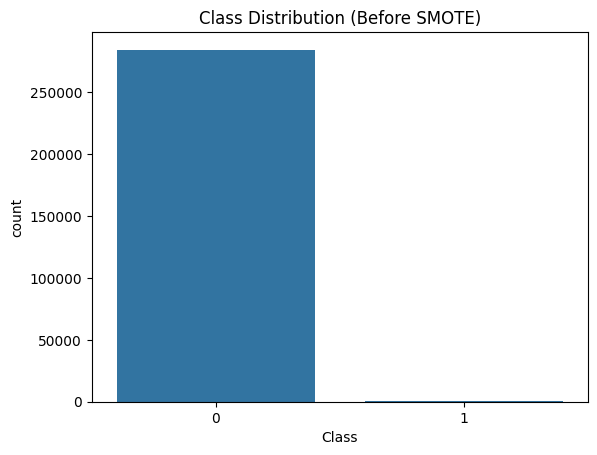

In [30]:
sns.countplot(x="Class", data=data)
plt.title("Class Distribution (Before SMOTE)")
plt.show()

In [31]:
X = data.drop('Class', axis=1)
y = data['Class']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPerformance Before SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Performance Before SMOTE
Accuracy: 0.9991456292499094
Confusion Matrix:
 [[85279    16]
 [   57    91]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.61      0.71       148

    accuracy                           1.00     85443
   macro avg       0.92      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [35]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_sm).value_counts())


Class Distribution After SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64


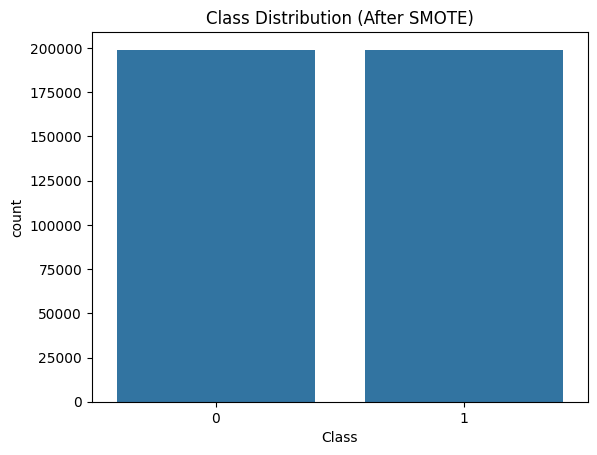

In [36]:
smote_df = pd.DataFrame(y_train_sm, columns=["Class"])

sns.countplot(x="Class", data=smote_df)
plt.title("Class Distribution (After SMOTE)")
plt.show()

In [37]:
model_sm = LogisticRegression(max_iter=1000)
model_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = model_sm.predict(X_test)

print("\nPerformance After SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sm))
print("Classification Report:\n", classification_report(y_test, y_pred_sm))


Performance After SMOTE
Accuracy: 0.9777278419531149
Confusion Matrix:
 [[83410  1885]
 [   18   130]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



Exercise 2:

Dataset:
https://uci-ics-mlr-prod.aws.uci.edu/dataset/17/breast%2Bcancer%2Bwisconsin%2Bdiagnostic?

Abstract: The Breast Cancer Wisconsin dataset contains diagnostic measurements of breast cell nuclei used to classify tumors as benign or malignant. The dataset exhibits class imbalance that may affect classification performance. Perform data preprocessing and exploratory analysis, followed by training a classification model for tumor prediction. Evaluate model performance using confusion matrix, accuracy, precision, recall, and F1-score. Apply SMOTE to balance the minority class and compare the performance of the model before and after resampling. Analyze the improvement in classification performance and discuss the effectiveness of SMOTE in handling imbalanced datasets.


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
columns = [
'id','diagnosis','radius_mean','texture_mean','perimeter_mean','area_mean',
'smoothness_mean','compactness_mean','concavity_mean','concave_points_mean',
'symmetry_mean','fractal_dimension_mean','radius_se','texture_se','perimeter_se',
'area_se','smoothness_se','compactness_se','concavity_se','concave_points_se',
'symmetry_se','fractal_dimension_se','radius_worst','texture_worst','perimeter_worst',
'area_worst','smoothness_worst','compactness_worst','concavity_worst',
'concave_points_worst','symmetry_worst','fractal_dimension_worst'
]

In [40]:
data = pd.read_csv("/content/wdbc.data", names=columns)

In [41]:
print("Dataset Shape:", data.shape)
print("\nClass Distribution:")
print(data['diagnosis'].value_counts())

Dataset Shape: (569, 32)

Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


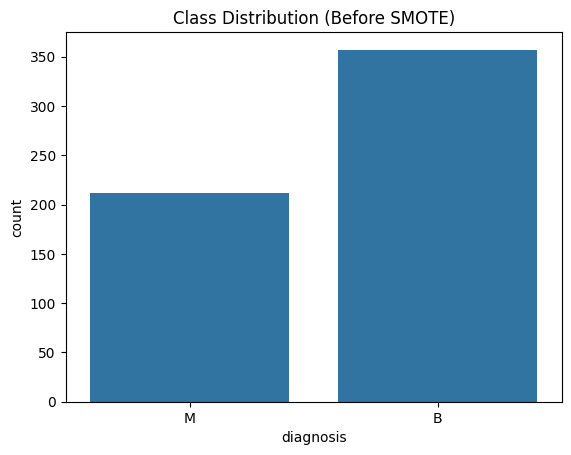

In [42]:
sns.countplot(x=data["diagnosis"])
plt.title("Class Distribution (Before SMOTE)")
plt.show()

In [43]:
data['diagnosis'] = data['diagnosis'].map({'M':1, 'B':0})

In [44]:
X = data.drop(['id','diagnosis'], axis=1)
y = data['diagnosis']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPerformance Before SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Performance Before SMOTE
Accuracy: 0.9005847953216374
Confusion Matrix:
 [[100   7]
 [ 10  54]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       107
           1       0.89      0.84      0.86        64

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



In [48]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_sm).value_counts())


Class Distribution After SMOTE:
diagnosis
1    250
0    250
Name: count, dtype: int64


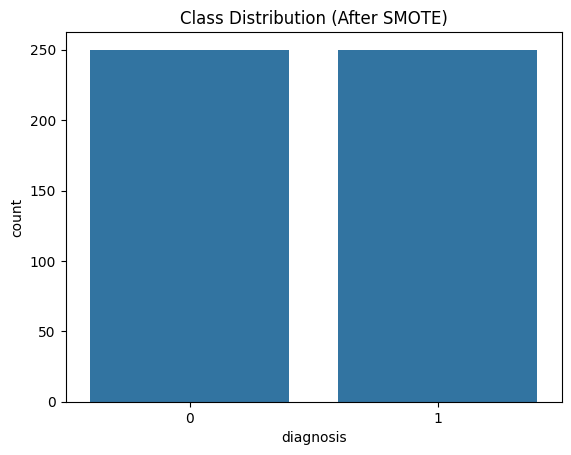

In [49]:
smote_df = pd.DataFrame(y_train_sm, columns=["diagnosis"])
sns.countplot(x="diagnosis", data=smote_df)
plt.title("Class Distribution (After SMOTE)")
plt.show()

In [50]:
model_sm = DecisionTreeClassifier(random_state=42)
model_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = model_sm.predict(X_test)

print("\nPerformance After SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sm))
print("Classification Report:\n", classification_report(y_test, y_pred_sm))


Performance After SMOTE
Accuracy: 0.9473684210526315
Confusion Matrix:
 [[103   4]
 [  5  59]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       107
           1       0.94      0.92      0.93        64

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171

